In [46]:
print("Human in the loop")

Human in the loop


In [47]:
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel
from langgraph.types import interrupt,Command
from langgraph.checkpoint.memory import InMemorySaver


class purchesState(BaseModel):
    item: str = ""
    price: int = 0
    confirmation: bool = False
    status: str = ""

def show_orders(state: purchesState):
    return {
        "status": f"Item: {state.item}, Price: {state.price}"
    }

def user_confirmation(state: purchesState):
    response = interrupt(
        "Do you want to confirm the purchase? (yes/no)"
    )

    if str(response).lower() == "yes":
        return {
            "confirmation": True,
            "status": "Confirmed"
        }

    return {
        "confirmation": False,
        "status": "Not Confirmed"
    }
def order_cancellation(state: purchesState):
    response = interrupt("Do you want to cancel the purchase? (yes/no)")

    if response.lower() == "yes":
        return {
            "confirmation": False,
            "status": "Cancelled"
        }

    return {}
def order_confirmation(state: purchesState):
    if state.confirmation:
        return {"status": "Order Confirmed"}

    return {"status": "Order Not Confirmed"}

def router(state: purchesState):
    if state.status == "Confirmed":
        return "order_confirmation"
    else:
        return "order_cancellation"
    


In [48]:
graph=StateGraph(purchesState)

graph.add_node("show_orders", show_orders)
graph.add_node("user_confirmation", user_confirmation)
graph.add_node("order_cancellation", order_cancellation)
graph.add_node("order_confirmation", order_confirmation)

graph.add_edge(START, "show_orders")
graph.add_edge("show_orders", "user_confirmation")
graph.add_conditional_edges(
    "user_confirmation",
    router,
    {
        "order_confirmation": "order_confirmation",
        "order_cancellation": "order_cancellation"
    }
)
graph.add_edge("order_cancellation", END)
graph.add_edge("order_confirmation", END)

In [49]:
final_graph = graph.compile(checkpointer=InMemorySaver())

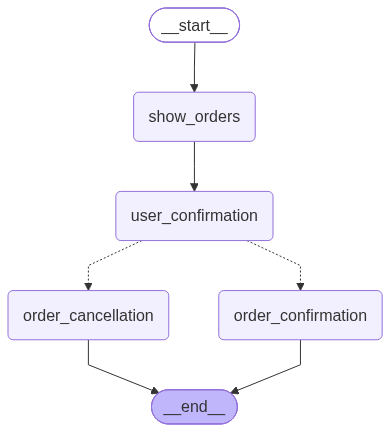

In [50]:
final_graph

In [51]:
res = final_graph.invoke(
        {"item": "Samsung S23", "price":12000},
        {"configurable": {"thread_id":"asd10"}}
    )

In [52]:
res

{'item': 'Samsung S23',
 'price': 12000,
 'status': 'Item: Samsung S23, Price: 12000',
 '__interrupt__': [Interrupt(value='Do you want to confirm the purchase? (yes/no)', id='40e28b6993989e7804ab44036a94a434', response_schema=None)]}

In [53]:
#res["__interrupt__"][0].value
print(res["__interrupt__"][0].value)

Do you want to confirm the purchase? (yes/no)


In [54]:
res = final_graph.invoke(
    Command(resume="no"),
    {"configurable": {"thread_id":"asd10"}}
)

print(res)

{'item': 'Samsung S23', 'price': 12000, 'confirmation': False, 'status': 'Not Confirmed', '__interrupt__': [Interrupt(value='Do you want to cancel the purchase? (yes/no)', id='633a1ac8da7789e8ef6764e914cccd71', response_schema=None)]}


In [56]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver


class purchesState(BaseModel):
    item: str = ""
    price: int = 0
    confirmation: bool = False
    status: str = ""


# ---------------- NODE 1 ----------------

def show_orders(state: purchesState):

    print("\n================ SHOW ORDER ================")
    print(f"Item       : {state.item}")
    print(f"Price      : ₹{state.price}")
    print("============================================")

    return {
        "status": f"Item: {state.item}, Price: {state.price}"
    }


# ---------------- NODE 2 ----------------

def user_confirmation(state: purchesState):

    print("\n========== USER CONFIRMATION NODE ==========")
    print(f"Current Item   : {state.item}")
    print(f"Current Price  : ₹{state.price}")
    print(f"Current Status : {state.status}")

    response = interrupt(
        "Do you want to confirm the purchase? (yes/no)"
    )

    print(f"\nUser Response : {response}")
    print(f"Response Type : {type(response).__name__}")

    if str(response).lower() == "yes":

        print(">>> User confirmed the purchase")

        return {
            "confirmation": True,
            "status": "Confirmed"
        }

    print(">>> User did NOT confirm the purchase")

    return {
        "confirmation": False,
        "status": "Not Confirmed"
    }


# ---------------- NODE 3 ----------------

def order_cancellation(state: purchesState):

    print("\n========== ORDER CANCELLATION NODE ==========")
    print(f"Item       : {state.item}")
    print(f"Price      : ₹{state.price}")
    print(f"Status     : {state.status}")

    response = interrupt(
        "Do you want to cancel the purchase? (yes/no)"
    )

    print(f"\nCancellation Response : {response}")
    print(f"Response Type         : {type(response).__name__}")

    if str(response).lower() == "yes":

        print(">>> User cancelled the order")

        return {
            "confirmation": False,
            "status": "Cancelled"
        }

    print(">>> User did NOT cancel the order")

    return {
        "status": "Order Not Cancelled"
    }


# ---------------- NODE 4 ----------------

def order_confirmation(state: purchesState):

    print("\n========== ORDER CONFIRMATION NODE ==========")
    print(f"Item         : {state.item}")
    print(f"Price        : ₹{state.price}")
    print(f"Confirmation : {state.confirmation}")
    print(f"Status       : {state.status}")

    if state.confirmation:

        print(">>> ORDER CONFIRMED SUCCESSFULLY")

        return {
            "status": "Order Confirmed"
        }

    print(">>> ORDER NOT CONFIRMED")

    return {
        "status": "Order Not Confirmed"
    }


# ---------------- ROUTER ----------------

def router(state: purchesState):

    print("\n================ ROUTER ================")
    print(f"Router received status : {state.status}")

    if state.status == "Confirmed":

        print(">>> Routing to: order_confirmation")

        return "order_confirmation"

    else:

        print(">>> Routing to: order_cancellation")

        return "order_cancellation"


# ---------------- GRAPH ----------------

graph = StateGraph(purchesState)

graph.add_node("show_orders", show_orders)
graph.add_node("user_confirmation", user_confirmation)
graph.add_node("order_cancellation", order_cancellation)
graph.add_node("order_confirmation", order_confirmation)


graph.add_edge(START, "show_orders")

graph.add_edge(
    "show_orders",
    "user_confirmation"
)

graph.add_conditional_edges(
    "user_confirmation",
    router,
    {
        "order_confirmation": "order_confirmation",
        "order_cancellation": "order_cancellation"
    }
)

graph.add_edge(
    "order_cancellation",
    END
)

graph.add_edge(
    "order_confirmation",
    END
)


# ---------------- COMPILE ----------------

checkpointer = InMemorySaver()

final_graph = graph.compile(
    checkpointer=checkpointer
)


# =====================================================
# FIRST INVOKE
# =====================================================

print("\n\n")
print("############################################")
print("#           FIRST GRAPH INVOKE             #")
print("############################################")


config = {
    "configurable": {
        "thread_id": "asd10"
    }
}


res = final_graph.invoke(
    {
        "item": "Samsung S23",
        "price": 12000
    },
    config
)


print("\n========== GRAPH PAUSED ==========")

print("Interrupt Message:")
print(res["__interrupt__"][0].value)

print("==================================")


# =====================================================
# RESUME
# =====================================================

print("\n\n")
print("############################################")
print("#              RESUME GRAPH                 #")
print("############################################")

res = final_graph.invoke(
    Command(resume="yes"),
    config
)


# =====================================================
# FINAL RESULT
# =====================================================

print("\n\n")
print("############################################")
print("#              FINAL RESULT                 #")
print("############################################")

print(f"Item         : {res['item']}")
print(f"Price        : ₹{res['price']}")
print(f"Confirmation : {res['confirmation']}")
print(f"Status       : {res['status']}")

print("############################################")




############################################
#           FIRST GRAPH INVOKE             #
############################################

================ SHOW ORDER ================
Item       : Samsung S23
Price      : ₹12000

========== USER CONFIRMATION NODE ==========
Current Item   : Samsung S23
Current Price  : ₹12000
Current Status : Item: Samsung S23, Price: 12000

========== GRAPH PAUSED ==========
Interrupt Message:
Do you want to confirm the purchase? (yes/no)



############################################
#              RESUME GRAPH                 #
############################################

========== USER CONFIRMATION NODE ==========
Current Item   : Samsung S23
Current Price  : ₹12000
Current Status : Item: Samsung S23, Price: 12000

User Response : yes
Response Type : str
>>> User confirmed the purchase

================ ROUTER ================
Router received status : Confirmed
>>> Routing to: order_confirmation

========== ORDER CONFIRMATION NODE ==========
Ite